In [1]:
import h5py
import numpy as np

h5_file = h5py.File('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/HDF5/photon_10MeVto2GeV_TEST.1000.LARCV2HDF5.hdf5', 'r')

In [21]:
event_idx = 9

vx_start = int(h5_file['voxels_offsets'][event_idx])
vx_end = int(h5_file['voxels_offsets'][event_idx + 1])

event_vx = h5_file['voxels_flat'][vx_start:vx_end]
ke = h5_file['ke_initial'][event_idx]

start_point = h5_file['start_points'][event_idx]

print("Event index:", event_idx)
print("Initial kinetic energy:", ke)
print("Number of voxels in event:", len(event_vx))
#print("First 10 voxels (x, y, z, dE):")
#for i in range(min(10, len(event_vx))):
#    print(f"  {i}: ({event_vx[i][0]}, {event_vx[i][1]}, {event_vx[i][2]}, {event_vx[i][3]})")
#print("Sum of energy:", np.sum(event_vx[:, 3]))  # Sum of dE values
positions_cm = event_vx[:, :3]  # Get the positions in cm
energy_per_voxel = event_vx[:, 3]  # Get the energy per voxel
#print("Positions (cm):", positions_cm[:10])  # Print first 10 positions
#print("Energy per voxel (MeV):", energy_per_voxel[:10])  #
#print("Number of events:", h5_file.attrs['n_events'])
distance_point_to_origin = np.linalg.norm(positions_cm, axis=1)
print("Minimum distance from origin to any voxel:", np.min(distance_point_to_origin))
print("Voxel with minimum distance from origin:", positions_cm[np.argmin(distance_point_to_origin)], "with energy:", energy_per_voxel[np.argmin(distance_point_to_origin)])
print("Voxel with minimum distance from origin:", np.argmin(distance_point_to_origin), "with energy:", energy_per_voxel[np.argmin(distance_point_to_origin)])
print("Start point:",start_point)

Event index: 9
Initial kinetic energy: 1421.1826
Number of voxels in event: 2944
Minimum distance from origin to any voxel: 3.09025
Voxel with minimum distance from origin: [-0.74411494  0.37191492 -2.9761748 ] with energy: 0.09654896
Voxel with minimum distance from origin: 2929 with energy: 0.09654896
Start point: [ 0.         0.        -3.4506836]


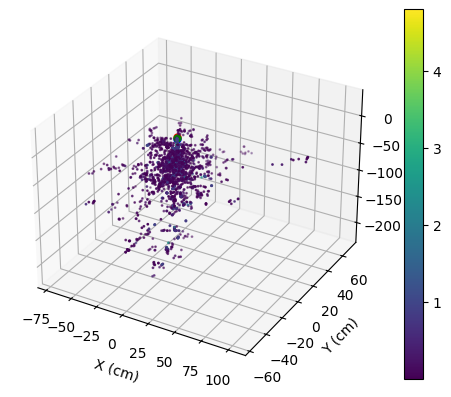

In [22]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower_x = event_vx[:, 0]
shower_y = event_vx[:, 1]
shower_z = event_vx[:, 2]
shower_dE = event_vx[:, 3]

shower = ax.scatter(shower_x,shower_y,shower_z,c=shower_dE, cmap='viridis', s=1)
ax.plot(0,0,0, marker='o', markersize=5, color='red')  # Mark the origin
ax.plot(start_point[0], start_point[1], start_point[2], marker='o', markersize=5, color='blue')  # Mark the start point
ax.plot(positions_cm[np.argmin(distance_point_to_origin)][0], positions_cm[np.argmin(distance_point_to_origin)][1], positions_cm[np.argmin(distance_point_to_origin)][2], marker='o', markersize=5, color='green')  # Mark the voxel closest to the origin
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z (cm)')
cbar = plt.colorbar(shower)

In [23]:
import ROOT
fname = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root' # Change this path if you are not on NERSC
#fname = 'LOCAL_PATH'
f = ROOT.TFile(fname)
f.ls()

TFile**		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root	
 TFile*		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root	
  KEY: TTree	sparse3d_pcluster_tree;1	pcluster tree
  KEY: TTree	sparse3d_pcluster_semantics_tree;1	pcluster_semantics tree
  KEY: TTree	cluster3d_pcluster_tree;1	pcluster tree
  KEY: TTree	cluster3d_pcluster_dedx_tree;1	pcluster_dedx tree
  KEY: TTree	particle_pcluster_tree;1	pcluster tree


In [24]:
import larcv
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
import spine
from spine.io.dataset.larcv import LArCVDataset
tree = f.Get("particle_pcluster_tree")

print('Number of entries', tree.GetEntries())
energy_init_values = []
start_x = []
start_y = []
start_z = []

for entry in range(tree.GetEntries()):
    if entry != event_idx: continue
    tree.GetEntry(entry)
    event = tree.particle_pcluster_branch
    print("Event:", entry)
    particles = event.as_vector()
    #print("Number of particles = ", len(particles))
    #print(particles[0].id())
    print("Children of first particle:")
    photon_id = particles[0].id()
    child_particles = [p for p in particles[1:] if p.parent_id() == photon_id ]
    print("Number of child particles = ", len(child_particles))
    first_child_idx = np.argmin([p.t() for p in child_particles])
    print([p.t() for p in child_particles])
    print(first_child_idx)
    print('First child position:', (child_particles[first_child_idx].x(), child_particles[first_child_idx].y(), child_particles[first_child_idx].z()))
    #for i in range(len(particles)):
        #if particles[i].parent_id() == particles[0].id():
         #   print("  Particle ID:", particles[i].id(), "Parent ID:", particles[i].parent_id(), "PDG Code:", particles[i].pdg_code(), "Creation Process:", particles[i].creation_process(), "Time:", particles[i].t(), "Energy Init:", particles[i].energy_init(), "Start Position:", (particles[i].x(), particles[i].y(), particles[i].z()))
    #for i in range(len(particles)):
    #    energy_init_values.append(particles[i].energy_init())
    #    start_x.append(particles[i].x())
    #    start_y.append(particles[i].y())
    #    start_z.append(particles[i].z())

#print("Energy init values:", energy_init_values)
#print("Start x:", start_x)
#print("Start y:", start_y)
#print("Start z:", start_z)
energy_init_values = np.array(energy_init_values)
start_x = np.array(start_x)
start_y = np.array(start_y)
start_z = np.array(start_z)

Number of entries 50
Event: 9
Children of first particle:
Number of child particles =  2
[1115.100084, 1115.100084]
0
First child position: (0.0, 0.0, -3.4506129999999997)
